In [1]:
!pip install seaborn

In [2]:
import os
os.chdir(r"E:\LogAnomalyDetector")
os.getcwd()


'E:\\LogAnomalyDetector'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [4]:
df = pd.read_csv("data/labeled_logs.csv")
df.head()


,timestamp,message,true_label
0,2025-07-23 16:11:43,LEVEL=INFO IP=192.168.1.100,0
1,2025-07-23 16:13:22,LEVEL=WARNING IP=192.168.1.101,0
2,2025-07-23 16:15:11,LEVEL=ERROR IP=nan,1
3,2025-07-23 16:18:53,LEVEL=INFO IP=nan,0
4,2025-07-23 16:21:08,LEVEL=CRITICAL IP=192.168.1.105,1


In [5]:
X_text = df["message"].astype(str)
y_true = df["true_label"].values

len(X_text), len(y_true)


(5, 5)

In [6]:
vectorizer = joblib.load("models/tfidf_vectorizer.joblib")
model = joblib.load("models/best_model.joblib")


In [7]:
X_all = vectorizer.transform(X_text)
X_all.shape


(5, 802)

In [8]:
y_prob = model.predict_proba(X_all)[:, 1]
y_pred = model.predict(X_all)

len(y_prob), len(y_pred)


ValueError: X has 802 features, but RandomForestClassifier is expecting 811 features as input.

In [ ]:
os.makedirs("reports", exist_ok=True)


In [ ]:
precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2)
plt.fill_between(recall, precision, alpha=0.15)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)

plt.savefig("reports/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred),
    "F1-score": f1_score(y_true, y_pred)
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.grid(axis="y")

plt.savefig("reports/model_performance_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

metrics


In [ ]:
import numpy as np

np.percentile(y_prob, [50, 60, 70, 80, 90, 95, 99])


In [ ]:
import os
os.makedirs("reports", exist_ok=True)


In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2)
plt.fill_between(recall, precision, alpha=0.15)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)

plt.savefig("reports/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred),
    "F1-score": f1_score(y_true, y_pred)
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.grid(axis="y")

plt.savefig("reports/model_performance_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
os.listdir("reports")


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
from scipy.sparse import hstack
from sklearn.metrics import confusion_matrix, f1_score

# Load data
df = pd.read_csv("data/hdfs_processed.csv")

# Load trained artifacts
rf = joblib.load("models/best_model.joblib")
vectorizer = joblib.load("models/tfidf_vectorizer.joblib")

# Load SAME test indices
idx_test = np.load("data/test_indices.npy")

df_test = df.loc[idx_test].copy()

print("✅ Data + model loaded")

✅ Data + model loaded


In [11]:
y_test = df_test["true_label"].values

In [13]:
print(type(y_test), len(y_test))

<class 'numpy.ndarray'> 400


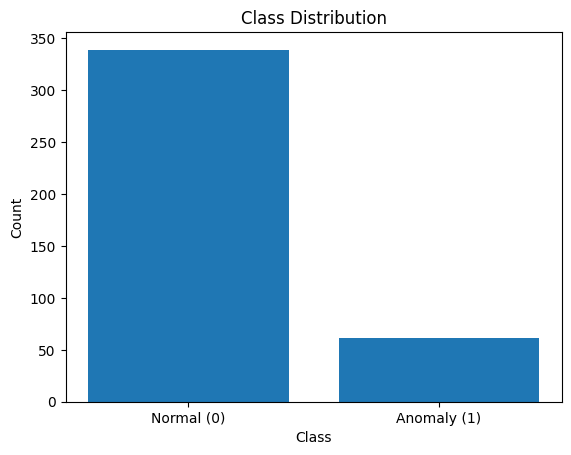


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_class_distribution.png

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink

# ==============================
# CREATE REPORTS FOLDER
# ==============================
output_dir = "reports"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "fig_class_distribution.png")

# ==============================
# PLOT
# ==============================
counts = np.bincount(y_test)

plt.figure()

plt.bar(["Normal (0)", "Anomaly (1)"], counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD LINK
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

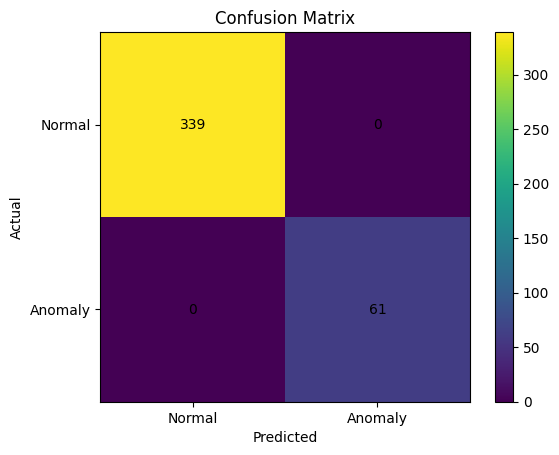


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_confusion_matrix.png

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.metrics import confusion_matrix
import joblib
import os
from IPython.display import FileLink

# ==============================
# LOAD DATA
# ==============================
X = sparse.load_npz("data/X_features.npz").tocsr()
y = np.loadtxt("data/y_labels.csv", delimiter=",", skiprows=1)

rf = joblib.load("models/best_model.joblib")

idx_test = np.load("data/test_indices.npy")

X_test = X[idx_test]
y_test = y[idx_test]

# ==============================
# PREDICTION
# ==============================
y_prob = rf.predict_proba(X_test)[:, 1]
threshold = 0.15
y_pred = (y_prob >= threshold).astype(int)

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

# ==============================
# SAVE PATH
# ==============================
output_dir = "reports"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "fig_confusion_matrix.png")

# ==============================
# PLOT
# ==============================
plt.figure()

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["Normal", "Anomaly"]
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

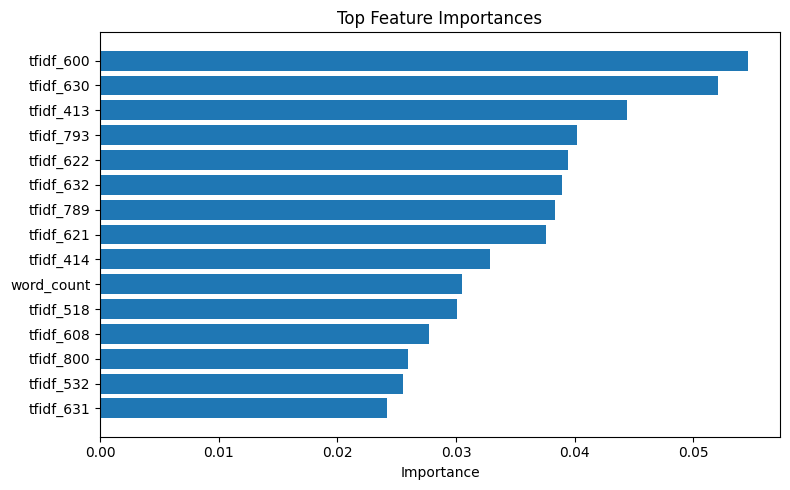


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_feature_importance.png

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from IPython.display import FileLink

# ==============================
# 1. LOAD MODEL
# ==============================
rf = joblib.load("models/best_model.joblib")

# ==============================
# 2. FEATURE IMPORTANCE
# ==============================
importances = rf.feature_importances_

# 🔥 DEFINE FEATURE NAMES (LAST 9 = STRUCTURED)
structured_names = [
    "len_text", "word_count", "has_number",
    "has_block", "long_text",
    "has_packet", "has_namenode",
    "has_replica", "has_storage"
]

n_total = len(importances)

feature_names = []
for i in range(n_total):
    if i < n_total - len(structured_names):
        feature_names.append(f"tfidf_{i}")
    else:
        feature_names.append(structured_names[i - (n_total - len(structured_names))])

# ==============================
# 3. TOP FEATURES (SORTED)
# ==============================
top_n = 15
indices = np.argsort(importances)[::-1][:top_n]  # descending

# ==============================
# 4. CREATE REPORTS FOLDER
# ==============================
output_dir = "reports"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "fig_feature_importance.png")

# ==============================
# 5. PLOT
# ==============================
plt.figure(figsize=(8, 5))

plt.barh(range(top_n), importances[indices][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in indices][::-1])

plt.xlabel("Importance")
plt.title("Top Feature Importances")

plt.tight_layout()

# ==============================
# 6. SAVE FILE
# ==============================
plt.savefig(file_path)
plt.show()

# ==============================
# 7. DOWNLOAD LINK
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

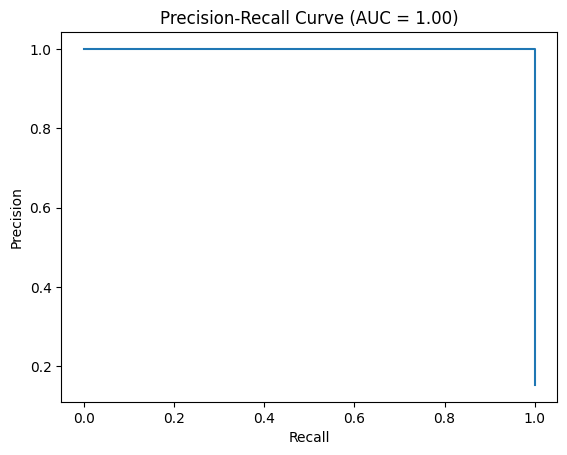


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_precision_recall_curve.png

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from scipy import sparse
import joblib
import os
from IPython.display import FileLink

# Load data
X = sparse.load_npz("data/X_features.npz").tocsr()
y = np.loadtxt("data/y_labels.csv", delimiter=",", skiprows=1)
rf = joblib.load("models/best_model.joblib")
idx_test = np.load("data/test_indices.npy")

X_test = X[idx_test]
y_test = y[idx_test]

# Probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

# PR curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Save path
os.makedirs("reports", exist_ok=True)
file_path = "reports/fig_precision_recall_curve.png"

# Plot
plt.figure()
plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

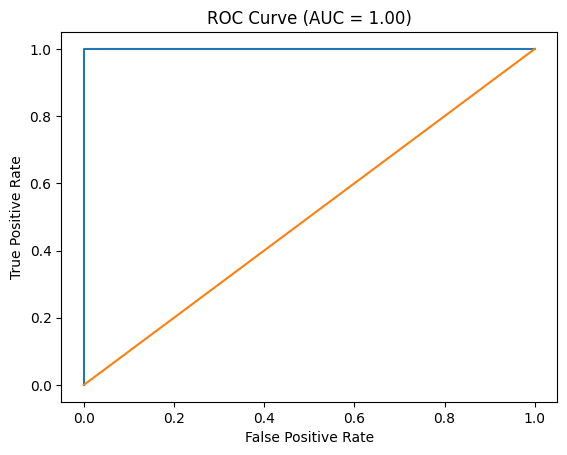


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_roc_curve.png

In [23]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

file_path = "reports/fig_roc_curve.png"

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # baseline
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

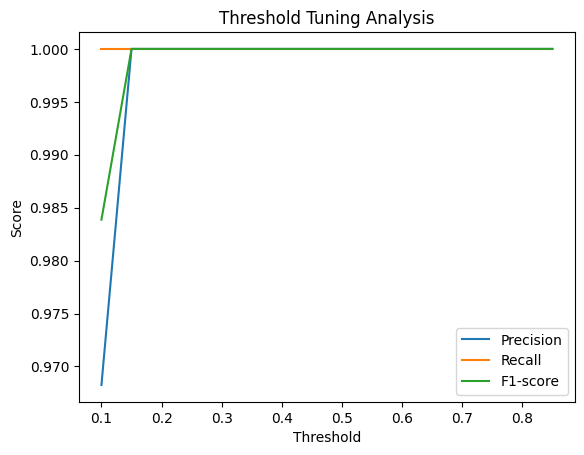


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_threshold_tuning.png

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))

file_path = "reports/fig_threshold_tuning.png"

plt.figure()

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1-score")

plt.title("Threshold Tuning Analysis")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

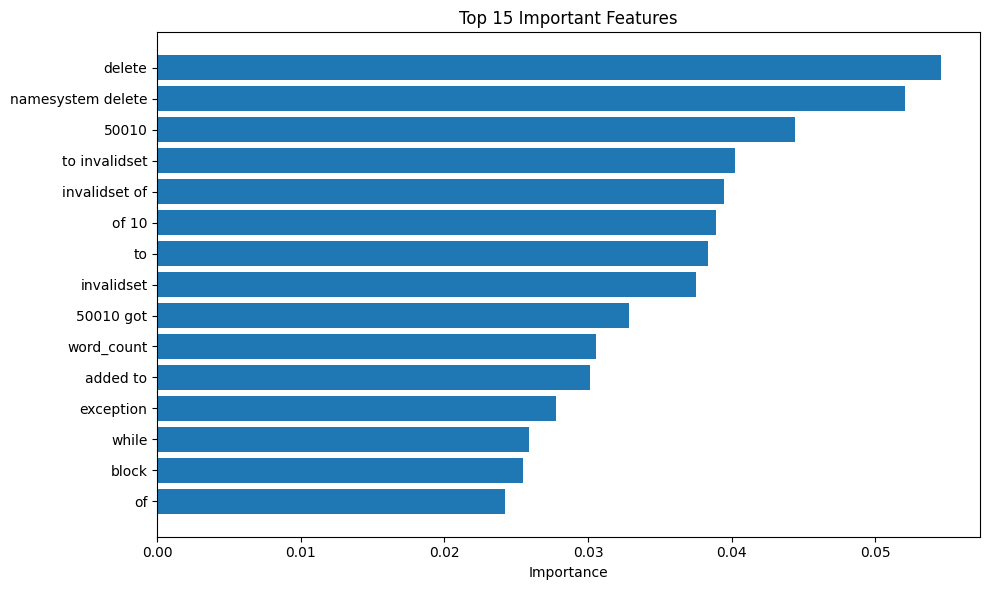


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_feature_importance_clean.png

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from IPython.display import FileLink

# ==============================
# LOAD MODEL + VECTORIZER
# ==============================
rf = joblib.load("models/best_model.joblib")
vectorizer = joblib.load("models/tfidf_vectorizer.joblib")

# ==============================
# FEATURE NAMES
# ==============================
tfidf_features = vectorizer.get_feature_names_out()

structured_features = [
    "text_length",
    "word_count",
    "has_number",
    "has_block",
    "long_text",
    "has_packet",
    "has_namenode",
    "has_replica",
    "has_storage"
]

all_features = list(tfidf_features) + structured_features

# ==============================
# IMPORTANCES
# ==============================
importances = rf.feature_importances_

top_n = 15
indices = np.argsort(importances)[-top_n:]

# Sort for better visualization
sorted_idx = indices[np.argsort(importances[indices])]

# ==============================
# SAVE PATH
# ==============================
os.makedirs("reports", exist_ok=True)
file_path = "reports/fig_feature_importance_clean.png"

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(10, 6))

labels = [all_features[i] for i in sorted_idx]
values = importances[sorted_idx]

plt.barh(range(top_n), values)
plt.yticks(range(top_n), labels)

plt.xlabel("Importance")
plt.title("Top 15 Important Features")

plt.tight_layout()
plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD LINK
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

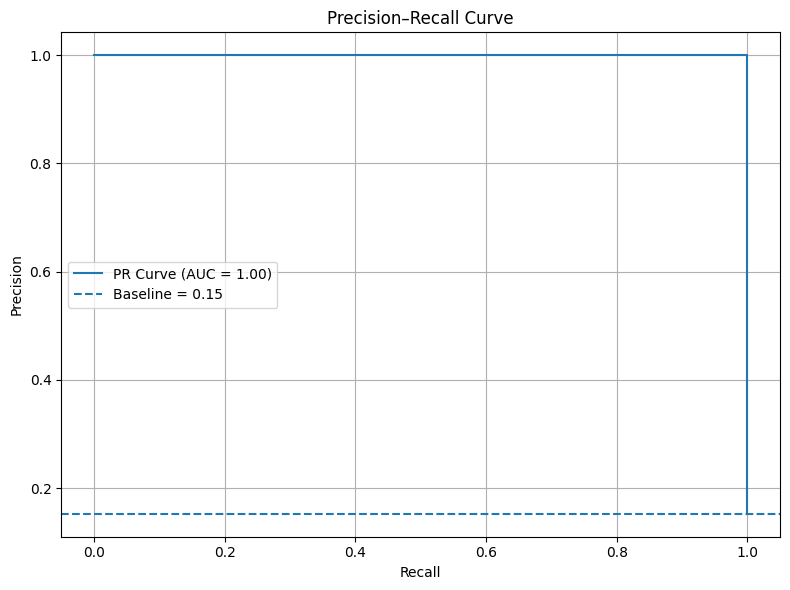


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_precision_recall_curve.png

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from scipy import sparse
import joblib
import os
from IPython.display import FileLink

# ==============================
# LOAD DATA (CORRECT WAY)
# ==============================
X = sparse.load_npz("data/X_features.npz").tocsr()
y = np.loadtxt("data/y_labels.csv", delimiter=",", skiprows=1)

rf = joblib.load("models/best_model.joblib")
idx_test = np.load("data/test_indices.npy")

X_test = X[idx_test]
y_test = y[idx_test]

# ==============================
# PREDICT PROBABILITIES
# ==============================
y_prob = rf.predict_proba(X_test)[:, 1]

# ==============================
# PRECISION-RECALL
# ==============================
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# ==============================
# BASELINE (IMPORTANT)
# ==============================
baseline = np.sum(y_test) / len(y_test)

# ==============================
# SAVE PATH
# ==============================
os.makedirs("reports", exist_ok=True)
file_path = "reports/fig_precision_recall_curve.png"

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(8, 6))

plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.axhline(y=baseline, linestyle="--", label=f"Baseline = {baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.legend()
plt.grid(True)


plt.tight_layout()
plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

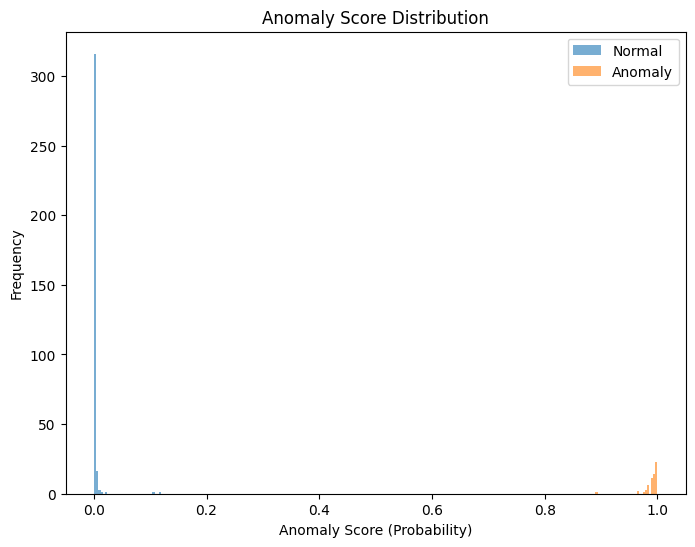


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_score_distribution.png

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import FileLink, display

# ==============================
# SEPARATE PROBABILITIES
# ==============================
normal_probs = y_prob[y_test == 0]
anomaly_probs = y_prob[y_test == 1]

# ==============================
# SAVE PATH
# ==============================
os.makedirs("reports", exist_ok=True)
file_path = "reports/fig_score_distribution.png"

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(8,6))

plt.hist(normal_probs, bins=30, alpha=0.6, label="Normal")
plt.hist(anomaly_probs, bins=30, alpha=0.6, label="Anomaly")

plt.xlabel("Anomaly Score (Probability)")
plt.ylabel("Frequency")
plt.title("Anomaly Score Distribution")
plt.legend()

plt.savefig(file_path)
plt.show()

# ==============================
# DOWNLOAD LINK
# ==============================
print("\n⬇ Download your graph:")
display(FileLink(file_path))

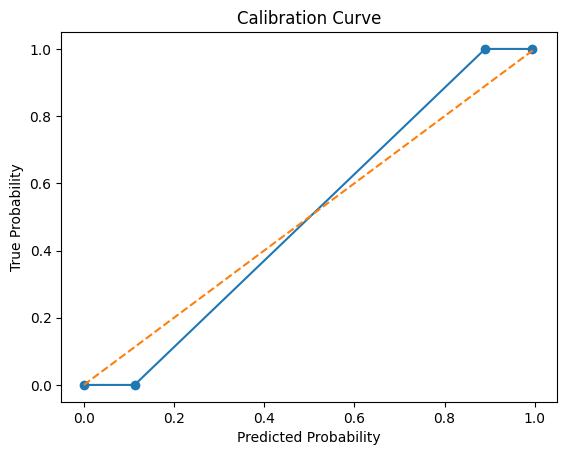


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_calibration_curve.png

In [33]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

file_path = "reports/fig_calibration_curve.png"

plt.figure()

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

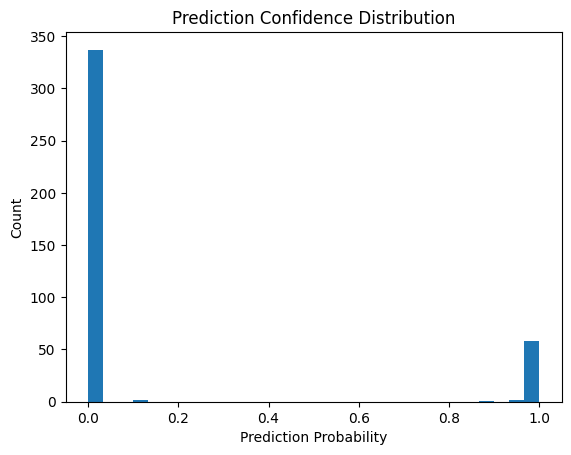


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_confidence_histogram.png

In [34]:
file_path = "reports/fig_confidence_histogram.png"

plt.figure()

plt.hist(y_prob, bins=30)

plt.xlabel("Prediction Probability")
plt.ylabel("Count")
plt.title("Prediction Confidence Distribution")

plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

In [36]:
# ==============================
# LOAD DATA + MODEL
# ==============================
import pandas as pd
import numpy as np
from scipy import sparse
import joblib

from sklearn.model_selection import train_test_split

# Load features
X = sparse.load_npz("data/X_features.npz")
y = pd.read_csv("data/y_labels.csv")["true_label"].values

# SAME split
indices = np.arange(len(y))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# LOAD MODELS
# ==============================
rf = joblib.load("models/best_model.joblib")

# If you didn't save LR/SVM → retrain quickly
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
svm = LinearSVC(class_weight="balanced")

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)

# ==============================
# PREDICTIONS
# ==============================
y_prob_rf = rf.predict_proba(X_test)[:, 1]
threshold = 0.15

y_pred_rf = (y_prob_rf >= threshold).astype(int)
y_pred_lr = lr.predict(X_test)
y_pred_svm = svm.predict(X_test)

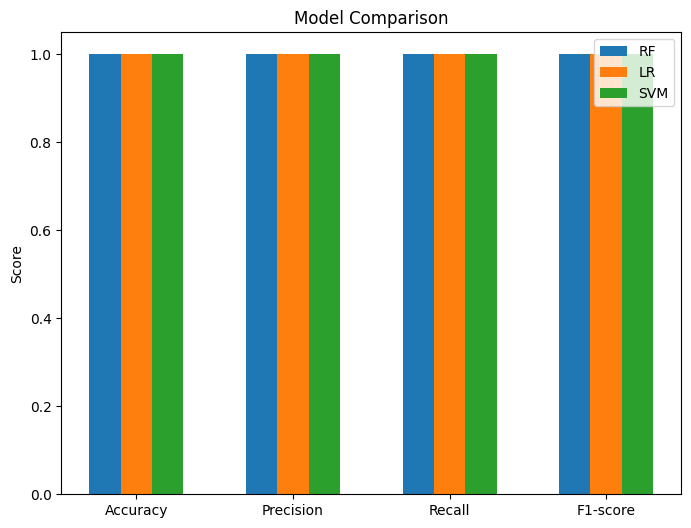

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink, display

# Metrics
models = ["Random Forest", "Logistic Regression", "SVM"]

rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

svm_scores = [
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm)
]

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

x = range(len(metrics))

plt.figure(figsize=(8,6))

width = 0.2
x = np.arange(len(metrics))

plt.bar(x - width, rf_scores, width, label="RF")
plt.bar(x, lr_scores, width, label="LR")
plt.bar(x + width, svm_scores, width, label="SVM")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()

plt.savefig("reports/fig_model_comparison_clean.png")
plt.show()

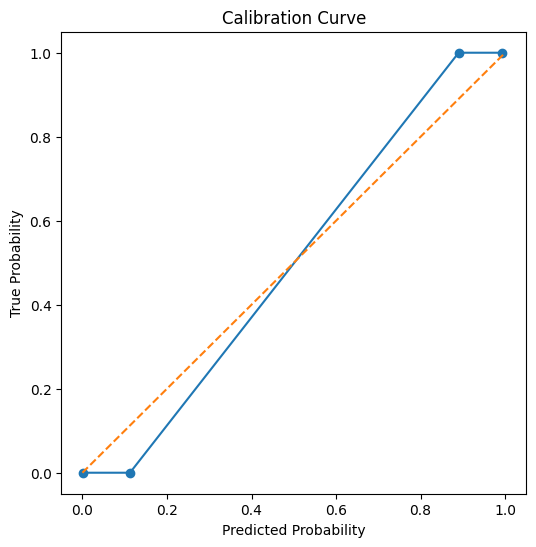


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_calibration_curve.png

In [38]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink, display

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")

file_path = "reports/fig_calibration_curve.png"
plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

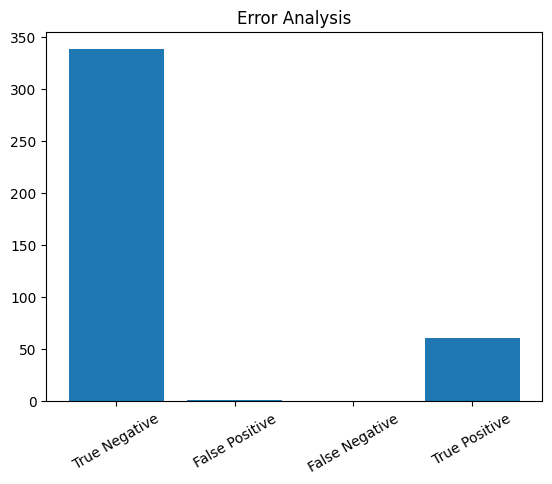


⬇ Download your graph:


E:\LogAnomalyDetector\reports\fig_error_analysis.png

In [39]:
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink, display

fp = 1
fn = 0
tp = 61
tn = 338

labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
values = [tn, fp, fn, tp]

plt.figure()
plt.bar(labels, values)

plt.title("Error Analysis")
plt.xticks(rotation=30)

file_path = "reports/fig_error_analysis.png"
plt.savefig(file_path)
plt.show()

print("\n⬇ Download your graph:")
display(FileLink(file_path))

In [3]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import joblib

# Load trained model
model = joblib.load(r"E:\LogAnomalyDetector\models\best_model.joblib")
vectorizer = joblib.load(r"E:\LogAnomalyDetector\models\tfidf_vectorizer.joblib")

# --- Get predicted probabilities ---
y_prob = model.predict_proba(X_test)[:, 1]

# --- Calibration data ---
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

# --- Plot ---
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')  # Perfect calibration line

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (Reliability Diagram)")

plt.savefig("reports/calibration_curve.png")
plt.show()

# --- Brier Score ---
brier = brier_score_loss(y_test, y_prob)
print("Brier Score:", brier)

NameError: name 'X_test' is not defined